In [ ]:
# =========================================================
# Dimension-wise runtime comparison (d = 2, 10, 20, ..., 100)
# TTL(Adam) vs ARTL(Adam, augmented parameter) with pre-sampled HOVR points
# =========================================================
import torch, torch.nn as nn, torch.optim as optim, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# =========================================================
# Model
# =========================================================
class SimpleMLP(nn.Module):
    def __init__(self, d_in=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 100), nn.Sigmoid(),
            nn.Linear(100, 100), nn.Sigmoid(),
            nn.Linear(100, 1)
        )
    def forward(self, x):
        return self.net(x)

# =========================================================
# Data generator (arbitrary dimension)
# =========================================================
def make_highdim_data(n=10000, d=2, noise=0.2, outlier_rate=0.03, seed=0):
    rng = np.random.RandomState(seed)
    X = rng.uniform(0, 2*np.pi, size=(n, d))
    y = np.sin(2 * X[:, 0]) * np.cos(2 * X[:, 1]) + rng.normal(0, noise, n)
    m = int(outlier_rate * n)
    if m > 0:
        idx = rng.choice(n, m, replace=False)
        y[idx] = 5 + rng.uniform(-0.1, 0.1, m)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# =========================================================
# Helper: build per-epoch random z pool on device
#   returns tensor of shape [epochs, M, d]
# =========================================================
@torch.no_grad()
def build_z_pool(x_train, epochs, M, device):
    xmin, _ = x_train.min(0)
    xmax, _ = x_train.max(0)
    d = x_train.shape[1]
    # uniform in [xmin, xmax] for each dim; broadcast over epochs and M
    rand = torch.rand((epochs, M, d), device=device)
    z_pool = xmin + (xmax - xmin) * rand
    return z_pool  # no requires_grad here; set per-epoch leaf later

# =========================================================
# TTL training (Adam)
# =========================================================
def train_TTL(model, x_train, y_train,
              h_ratio=0.9, lr=0.01, epochs=500,
              device='cuda', use_amp=True):
    start_total = time.perf_counter()
    model = model.to(device)
    x_train, y_train = x_train.to(device), y_train.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    n = len(y_train); h = int(h_ratio * n)

    for _ in range(epochs):
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            y_pred = model(x_train).squeeze()
            resid = (y_pred - y_train)**2
            ttl = torch.topk(resid, h, largest=False).values.mean()
            loss = 0.5 * ttl
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()

    total_time = time.perf_counter() - start_total
    return total_time

# =========================================================
# ARTL (Augmented Robust Trimmed Loss) with pre-sampled random z per epoch
# =========================================================
def train_ARTL(model, x_train, y_train,
               k=1, q=2, lam=1e-3, h_ratio=0.9,
               lr_theta=0.01, lr_xi=0.005,
               alpha=50.0, epochs=500, M=16,
               device='cuda', use_amp=True, grad_clip=None):
    """
    Full ARTL with augmented parameter ξ (soft trimming).
    HOVR term uses pre-sampled random z for each epoch (different z every epoch).
    """
    start_total = time.perf_counter()
    model = model.to(device)
    x_train, y_train = x_train.to(device), y_train.to(device)
    n = len(y_train); h = int(h_ratio * n)

    # augmented parameter ξ
    xi = torch.nn.Parameter(torch.zeros(n, device=device))

    opt = optim.Adam([
        {'params': model.parameters(), 'lr': lr_theta},
        {'params': [xi], 'lr': lr_xi}
    ])
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    # pre-sample z for all epochs on device
    z_pool = build_z_pool(x_train, epochs=epochs, M=M, device=device)  # [E, M, d]

    for ep in range(epochs):
        opt.zero_grad(set_to_none=True)

        # ===== soft TTL term =====
        with torch.amp.autocast('cuda', enabled=use_amp):
            y_pred = model(x_train).squeeze()
            resid = (y_pred - y_train) ** 2
            weights = torch.sigmoid(alpha * (xi - resid))  # soft trimming
            ttl_soft = (weights * resid).mean()

        # ===== HOVR term (use pre-sampled z for this epoch) =====
        # make a leaf tensor with requires_grad=True
        z = z_pool[ep].detach().clone().requires_grad_(True)  # [M, d]
        with torch.amp.autocast('cuda', enabled=use_amp):
            fz = model(z).sum()
        grad = torch.autograd.grad(fz, z, create_graph=False, retain_graph=False)[0]
        if k > 1:
            # (optional) higher-order derivatives if needed
            for _ in range(1, k):
                grad = torch.autograd.grad(grad.sum(), z, create_graph=False, retain_graph=False)[0]
        hovr = lam * (torch.abs(grad)**q).mean()

        with torch.amp.autocast('cuda', enabled=use_amp):
            loss = 0.5 * ttl_soft + hovr

        scaler.scale(loss).backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(opt); scaler.update()

    total_time = time.perf_counter() - start_total
    return total_time

# =========================================================
# Experiment Configuration
# =========================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 500
REPEAT = 3
LR_THETA = 0.01
LR_XI = 0.005
H_RATIO = 0.9
USE_AMP = True
M = 16
LAM = 1e-3
K = 1
Q = 2
N = 10000
ALPHA = 50.0

dims = [2] + list(range(10, 101, 10))  # 2,10,20,...,100

# =========================================================
# Run experiment across dimensions
# =========================================================
results = []
for d in dims:
    print(f"=== Dimension {d} ===")
    x_train, y_train = make_highdim_data(n=N, d=d, noise=0.2, outlier_rate=0.03, seed=0)
    ttl_times, artl_times = [], []
    for r in range(REPEAT):
        ttl_t = train_TTL(SimpleMLP(d), x_train, y_train,
                          h_ratio=H_RATIO, lr=LR_THETA, epochs=EPOCHS,
                          device=device, use_amp=USE_AMP)
        artl_t = train_ARTL(SimpleMLP(d), x_train, y_train,
                            k=K, q=Q, lam=LAM, h_ratio=H_RATIO,
                            lr_theta=LR_THETA, lr_xi=LR_XI,
                            alpha=ALPHA, epochs=EPOCHS, M=M,
                            device=device, use_amp=USE_AMP)
        ttl_times.append(ttl_t); artl_times.append(artl_t)
    results.append({
        "Dimension": d,
        "TTL_Total_s": np.mean(ttl_times),
        "ARTL_Total_s": np.mean(artl_times),
        "TTL_sd_s": np.std(ttl_times, ddof=1),
        "ARTL_sd_s": np.std(artl_times, ddof=1)
    })

Figure 3

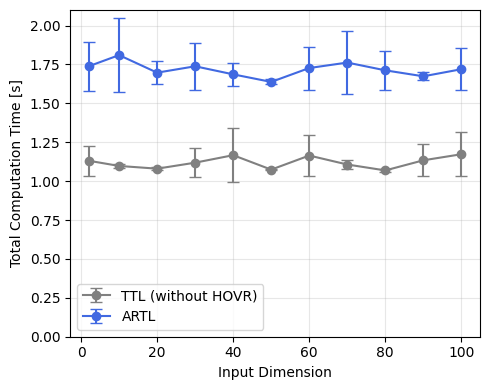

In [ ]:
# =========================================================
# Plot scaling behavior (mean ± 1 SD)
# =========================================================
plt.figure(figsize=(5,4))
plt.errorbar(df["Dimension"], df["TTL_Total_s"],  yerr=df["TTL_sd_s"],
             fmt='-o', capsize=4, label="TTL (without HOVR)", color='gray')
plt.errorbar(df["Dimension"], df["ARTL_Total_s"], yerr=df["ARTL_sd_s"],
             fmt='-o', capsize=4, label="ARTL", color='royalblue')
plt.xlabel("Input Dimension")
plt.ylabel("Total Computation Time [s]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()